# 09 — Appendix: Smart Initialization

This notebook is an isolated comparison of target-dependent smart initialization against the current best target-independent GA setup.


## 0. Setup

The notebook changes into the repository root so paths match the other notebooks. No project source files are edited by this experiment.


In [1]:
import os
import sys
import time
import csv
import io
from contextlib import contextmanager, redirect_stdout
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import src.ga as ga
from src.ga import evaluate_population
from src.fitness import downscale_target, evaluate, load_target
from src.rendering import render_individual_fast as render_individual
from src.representation import (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    NUM_TRIANGLES,
    random_triangle,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

target = load_target()
target_downscaled = downscale_target(target)


## 1. Notebook-local smart initializer

- draw the same random triangle geometry as the normal initializer;
- compute the triangle centroid;
- overwrite the triangle RGB genes with the target pixel at that centroid;
- leave alpha random.

The initializer still consumes the same random RGB values as the normal triangle generator before overwriting them, so the geometry and random stream stay comparable for a fixed seed.


In [2]:
def smart_random_triangle(rng: np.random.Generator, target_image: np.ndarray) -> np.ndarray:
    """Target-dependent triangle initialization copied from the pre-5e370a0 implementation."""
    triangle = random_triangle(rng)

    cx = int((triangle[0] + triangle[2] + triangle[4]) / 3)
    cy = int((triangle[1] + triangle[3] + triangle[5]) / 3)
    cx = int(np.clip(cx, 0, IMAGE_WIDTH - 1))
    cy = int(np.clip(cy, 0, IMAGE_HEIGHT - 1))

    triangle[6] = float(target_image[cy, cx, 0])
    triangle[7] = float(target_image[cy, cx, 1])
    triangle[8] = float(target_image[cy, cx, 2])
    return triangle


def smart_random_individual(
    rng: np.random.Generator,
    target_image: np.ndarray,
    num_triangles: int = NUM_TRIANGLES,
) -> np.ndarray:
    """Generate one target-dependent individual for this notebook only."""
    return np.array(
        [smart_random_triangle(rng, target_image) for _ in range(num_triangles)],
        dtype=np.float32,
    )


def smart_initialize_population(
    pop_size: int,
    rng: np.random.Generator,
    target_image: np.ndarray,
    num_triangles: int = NUM_TRIANGLES,
) -> np.ndarray:
    """Create a population whose triangle colors are sampled from the target."""
    return np.array(
        [smart_random_individual(rng, target_image, num_triangles) for _ in range(pop_size)],
        dtype=np.float32,
    )


## 2. Initial population comparison

Before running the full GA, compare the quality of the initial populations alone. This measures the direct advantage introduced by looking at the target during initialization.


In [3]:
def summarize_initial_population(seed: int, pop_size: int = 150) -> dict:
    random_rng = np.random.default_rng(seed)
    smart_rng = np.random.default_rng(seed)

    random_pop = ga.initialize_population(pop_size, random_rng)
    smart_pop = smart_initialize_population(pop_size, smart_rng, target)

    random_fit = evaluate_population(
        random_pop,
        target,
        fast_fitness=True,
        target_downscaled=target_downscaled,
        fitness_mode="rmse",
    )
    smart_fit = evaluate_population(
        smart_pop,
        target,
        fast_fitness=True,
        target_downscaled=target_downscaled,
        fitness_mode="rmse",
    )

    return {
        "seed": seed,
        "random_best": float(np.min(random_fit)),
        "random_avg": float(np.mean(random_fit)),
        "smart_best": float(np.min(smart_fit)),
        "smart_avg": float(np.mean(smart_fit)),
        "best_delta": float(np.min(random_fit) - np.min(smart_fit)),
        "avg_delta": float(np.mean(random_fit) - np.mean(smart_fit)),
    }


INITIAL_SEEDS = [42, 123, 456, 789, 1001]
initial_rows = [summarize_initial_population(seed) for seed in INITIAL_SEEDS]

print("Initial population fitness, downscaled RMSE. Lower is better.")
print(f"{'seed':>6} | {'random best':>11} | {'smart best':>10} | {'best delta':>10} | {'random avg':>10} | {'smart avg':>9} | {'avg delta':>9}")
print("-" * 93)
for row in initial_rows:
    print(
        f"{row['seed']:>6} | "
        f"{row['random_best']:>11.4f} | "
        f"{row['smart_best']:>10.4f} | "
        f"{row['best_delta']:>10.4f} | "
        f"{row['random_avg']:>10.4f} | "
        f"{row['smart_avg']:>9.4f} | "
        f"{row['avg_delta']:>9.4f}"
    )


Initial population fitness, downscaled RMSE. Lower is better.
  seed | random best | smart best | best delta | random avg | smart avg | avg delta
---------------------------------------------------------------------------------------------
    42 |     66.2178 |    56.5701 |     9.6478 |    74.0890 |   63.0124 |   11.0766
   123 |     65.7565 |    55.3206 |    10.4359 |    74.3625 |   62.9773 |   11.3852
   456 |     65.3413 |    56.7946 |     8.5467 |    74.6786 |   63.4500 |   11.2286
   789 |     66.4673 |    55.6697 |    10.7976 |    74.4521 |   63.5525 |   10.8997
  1001 |     65.8197 |    54.7106 |    11.1091 |    75.0361 |   63.0745 |   11.9616


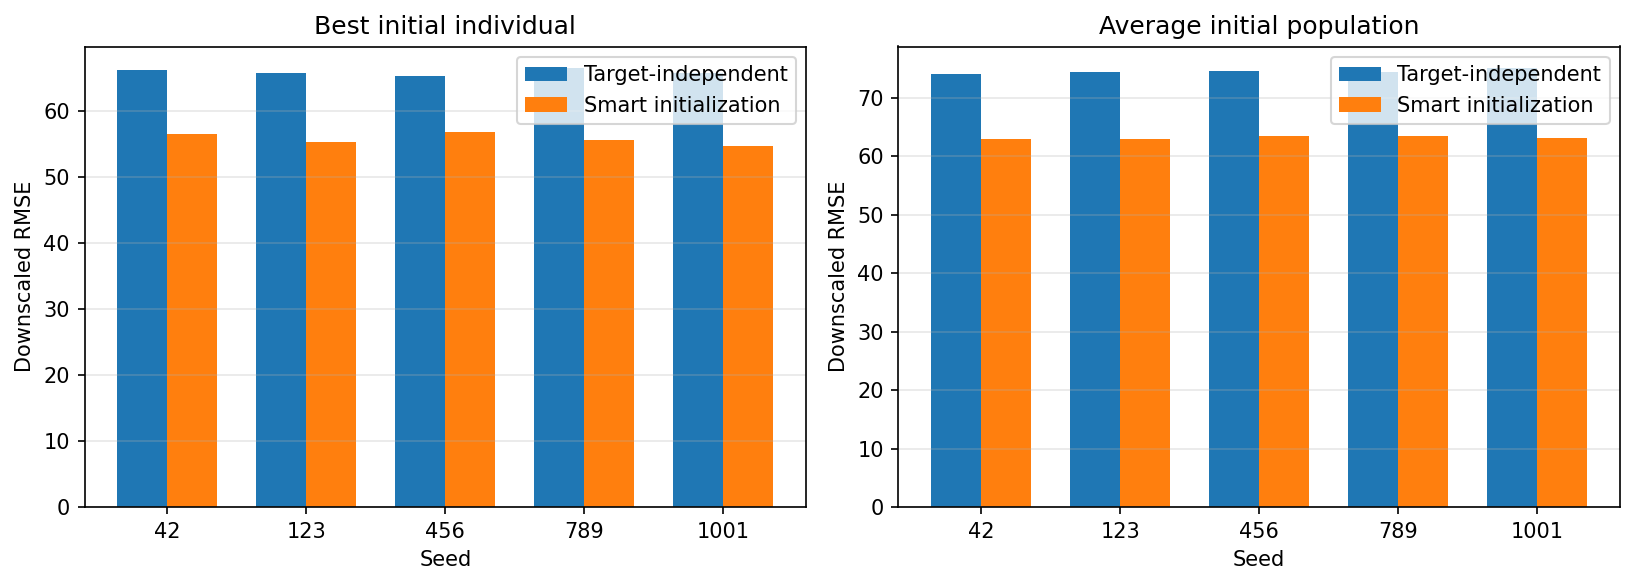

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.arange(len(initial_rows))
labels = [str(row["seed"]) for row in initial_rows]

axes[0].bar(x - 0.18, [row["random_best"] for row in initial_rows], width=0.36, label="Target-independent")
axes[0].bar(x + 0.18, [row["smart_best"] for row in initial_rows], width=0.36, label="Smart initialization")
axes[0].set_title("Best initial individual")
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("Downscaled RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(x - 0.18, [row["random_avg"] for row in initial_rows], width=0.36, label="Target-independent")
axes[1].bar(x + 0.18, [row["smart_avg"] for row in initial_rows], width=0.36, label="Smart initialization")
axes[1].set_title("Average initial population")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Downscaled RMSE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Current best configuration

This is the current best target-independent setup used by the final-result notebook. Snapshot writing is disabled here because it does not affect the GA trajectory and would only create extra files during comparison runs.

The default comparison below uses the same operators and hyperparameters but a shorter generation budget for iteration speed. Set `COMPARISON_CONFIG = dict(CURRENT_BEST_CONFIG)` to repeat the exact 3000-generation budget.


In [5]:
CURRENT_BEST_CONFIG = {
    "pop_size": 150,
    "generations": 3000,
    "selection_method": "rank",
    "tournament_k": 3,
    "crossover_method": "uniform",
    "crossover_rate": 0.8,
    "mutation_method": "multi",
    "mutation_rate": 0.05,
    "sigma": 10.0,
    "elite_size": 2,
    "early_stop_generations": 500,
    "snapshot_interval": 0,
    "snapshot_dir": "data/snapshots_smart_initialization",
    "fast_fitness": True,
    "fitness_mode": "rmse",
    "local_search_iterations": 5,
    "fitness_sharing": False,
    "restricted_mating": False,
    "restricted_mating_pool": 5,
}

COMPARISON_CONFIG = {
    **CURRENT_BEST_CONFIG,
    "generations": 300,
    "early_stop_generations": 0,
}

COMPARISON_SEEDS = [42, 123, 456]
VERBOSE_GA = False
SAVE_COMPARISON_CSV = True
COMPARISON_CSV = Path("experiments/logs/smart_initialization_comparison.csv")

print("Comparison budget:")
for key in ["pop_size", "generations", "selection_method", "crossover_method", "mutation_method", "mutation_rate", "sigma", "elite_size", "fast_fitness", "local_search_iterations"]:
    print(f"  {key}: {COMPARISON_CONFIG[key]}")
print(f"  seeds: {COMPARISON_SEEDS}")


Comparison budget:
  pop_size: 150
  generations: 300
  selection_method: rank
  crossover_method: uniform
  mutation_method: multi
  mutation_rate: 0.05
  sigma: 10.0
  elite_size: 2
  fast_fitness: True
  local_search_iterations: 5
  seeds: [42, 123, 456]


## 4. GA comparison runner

`run_ga_with_initialization` temporarily patches `src.ga.initialize_population` so the rest of the GA loop remains exactly the current implementation. The patch is restored after each run.


In [6]:
@contextmanager
def use_initializer(mode: str, target_image: np.ndarray):
    original_initializer = ga.initialize_population

    def patched_initializer(
        pop_size: int,
        rng: np.random.Generator,
        num_triangles: int = NUM_TRIANGLES,
    ) -> np.ndarray:
        if mode == "smart":
            return smart_initialize_population(
                pop_size=pop_size,
                rng=rng,
                target_image=target_image,
                num_triangles=num_triangles,
            )
        return original_initializer(pop_size, rng, num_triangles=num_triangles)

    ga.initialize_population = patched_initializer
    try:
        yield
    finally:
        ga.initialize_population = original_initializer


def run_ga_with_initialization(mode: str, seed: int, config: dict) -> dict:
    t0 = time.time()
    with use_initializer(mode, target):
        if VERBOSE_GA:
            best_individual, best_downscaled, history = ga.run_ga(
                target_image=target,
                seed=seed,
                **config,
            )
        else:
            with redirect_stdout(io.StringIO()):
                best_individual, best_downscaled, history = ga.run_ga(
                    target_image=target,
                    seed=seed,
                    **config,
                )

    elapsed = time.time() - t0
    full_rmse = evaluate(best_individual, target, fitness_mode="rmse")

    return {
        "mode": mode,
        "seed": seed,
        "best_individual": best_individual,
        "history": history,
        "best_downscaled_rmse": float(best_downscaled),
        "final_downscaled_rmse": float(history["best_fitness"][-1]),
        "final_full_rmse": float(full_rmse),
        "elapsed_sec": elapsed,
    }


def run_comparison(config: dict, seeds: list[int]) -> list[dict]:
    results = []
    for seed in seeds:
        for mode in ["target_independent", "smart"]:
            print(f"Running {mode:>18} | seed={seed} | generations={config['generations']}")
            result = run_ga_with_initialization(mode, seed, config)
            results.append(result)
            print(
                f"  final downscaled RMSE={result['final_downscaled_rmse']:.4f} | "
                f"full RMSE={result['final_full_rmse']:.4f} | "
                f"time={result['elapsed_sec'] / 60:.1f} min"
            )
    return results


In [7]:
comparison_results = run_comparison(COMPARISON_CONFIG, COMPARISON_SEEDS)


Running target_independent | seed=42 | generations=300
  final downscaled RMSE=30.9304 | full RMSE=31.8073 | time=1.8 min
Running              smart | seed=42 | generations=300
  final downscaled RMSE=29.1581 | full RMSE=30.2837 | time=1.8 min
Running target_independent | seed=123 | generations=300
  final downscaled RMSE=33.1714 | full RMSE=34.0013 | time=1.8 min
Running              smart | seed=123 | generations=300
  final downscaled RMSE=30.1658 | full RMSE=31.2292 | time=1.7 min
Running target_independent | seed=456 | generations=300
  final downscaled RMSE=31.9848 | full RMSE=32.7982 | time=1.7 min
Running              smart | seed=456 | generations=300
  final downscaled RMSE=31.2783 | full RMSE=32.3882 | time=1.8 min


## 5. Numeric summary

The main comparison value is full-resolution RMSE at the end of each run. Downscaled RMSE is kept because it is the optimization metric when `fast_fitness=True`.


In [8]:
def summarize_results(results: list[dict]) -> dict:
    summary = {}
    for mode in sorted({r["mode"] for r in results}):
        subset = [r for r in results if r["mode"] == mode]
        full = np.array([r["final_full_rmse"] for r in subset], dtype=float)
        downscaled = np.array([r["final_downscaled_rmse"] for r in subset], dtype=float)
        summary[mode] = {
            "n": len(subset),
            "full_mean": float(np.mean(full)),
            "full_std": float(np.std(full)),
            "full_min": float(np.min(full)),
            "downscaled_mean": float(np.mean(downscaled)),
            "downscaled_std": float(np.std(downscaled)),
            "elapsed_min": float(np.sum([r["elapsed_sec"] for r in subset]) / 60.0),
        }
    return summary


summary = summarize_results(comparison_results)

print(f"{'mode':>20} | {'n':>3} | {'full mean':>10} | {'full std':>9} | {'full min':>9} | {'down mean':>10} | {'down std':>8} | {'min':>7}")
print("-" * 101)
for mode, row in summary.items():
    print(
        f"{mode:>20} | "
        f"{row['n']:>3} | "
        f"{row['full_mean']:>10.4f} | "
        f"{row['full_std']:>9.4f} | "
        f"{row['full_min']:>9.4f} | "
        f"{row['downscaled_mean']:>10.4f} | "
        f"{row['downscaled_std']:>8.4f} | "
        f"{row['elapsed_min']:>7.1f}"
    )

if SAVE_COMPARISON_CSV:
    COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)
    with COMPARISON_CSV.open("w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "mode",
                "seed",
                "generations",
                "final_downscaled_rmse",
                "final_full_rmse",
                "elapsed_sec",
            ],
        )
        writer.writeheader()
        for r in comparison_results:
            writer.writerow({
                "mode": r["mode"],
                "seed": r["seed"],
                "generations": COMPARISON_CONFIG["generations"],
                "final_downscaled_rmse": r["final_downscaled_rmse"],
                "final_full_rmse": r["final_full_rmse"],
                "elapsed_sec": r["elapsed_sec"],
            })
    print(f"Saved comparison CSV to {COMPARISON_CSV}")


                mode |   n |  full mean |  full std |  full min |  down mean | down std |     min
-----------------------------------------------------------------------------------------------------
               smart |   3 |    31.3004 |    0.8606 |   30.2837 |    30.2007 |   0.8659 |     5.2
  target_independent |   3 |    32.8689 |    0.8971 |   31.8073 |    32.0288 |   0.9154 |     5.3
Saved comparison CSV to experiments/logs/smart_initialization_comparison.csv


## 6. Convergence plots

The left panel compares average best fitness over generations. The right panel compares the final full-resolution RMSE distribution across seeds.


/var/folders/4c/8bmfn3w93fxfhym9zg0nt2q00000gn/T/ipykernel_3974/1094636992.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot(final_full, labels=[labels[m] for m in modes], patch_artist=True)


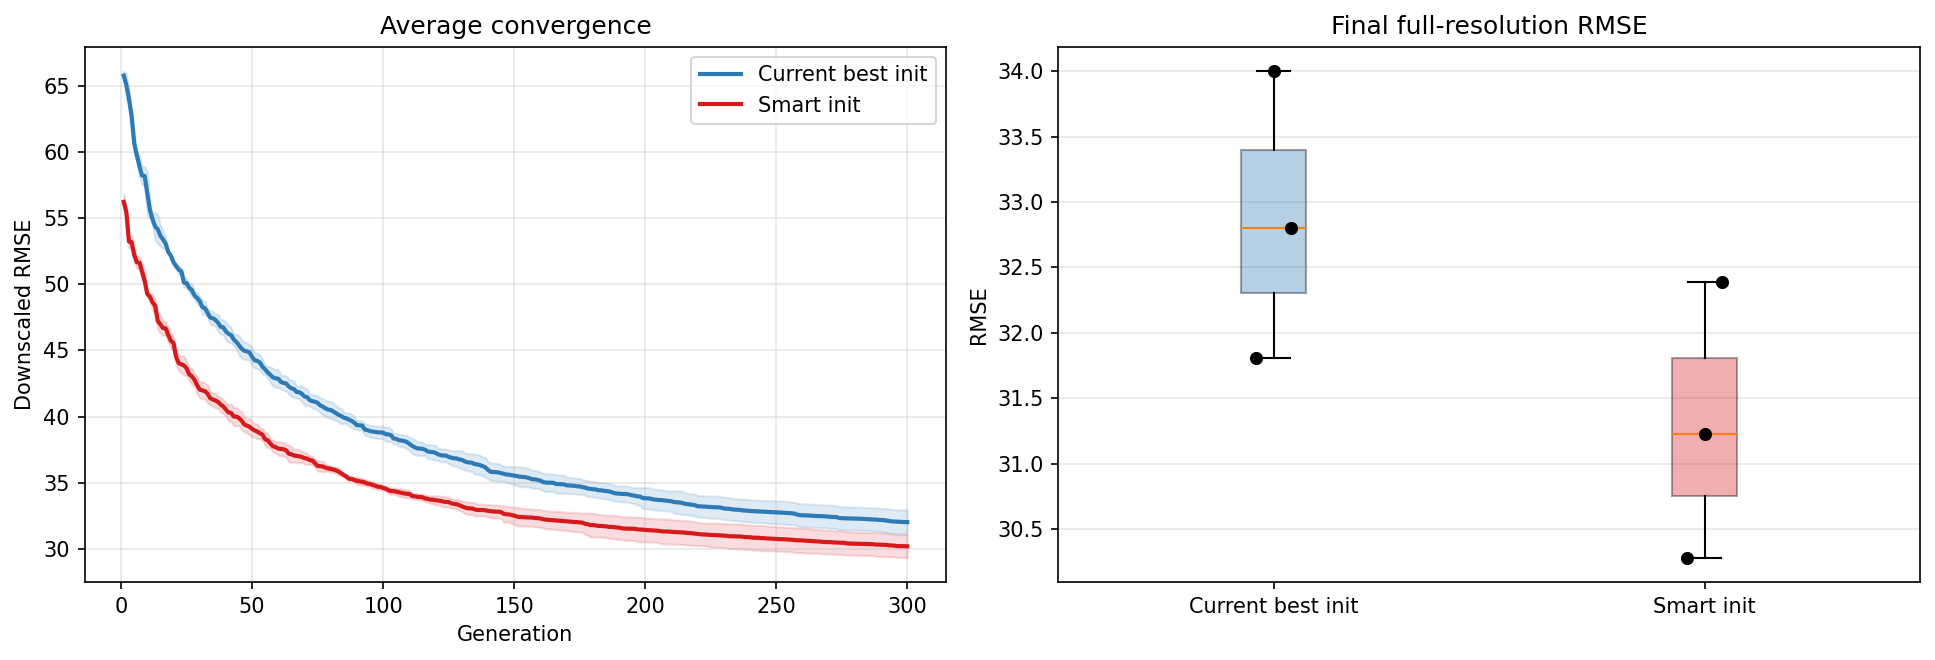

In [9]:
def histories_for_mode(results: list[dict], mode: str) -> np.ndarray:
    histories = [r["history"]["best_fitness"] for r in results if r["mode"] == mode]
    min_len = min(len(h) for h in histories)
    return np.array([h[:min_len] for h in histories], dtype=float)


modes = ["target_independent", "smart"]
colors = {"target_independent": "#2C7BB6", "smart": "#D7191C"}
labels = {"target_independent": "Current best init", "smart": "Smart init"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for mode in modes:
    h = histories_for_mode(comparison_results, mode)
    mean = h.mean(axis=0)
    std = h.std(axis=0)
    x = np.arange(1, len(mean) + 1)
    axes[0].plot(x, mean, label=labels[mode], color=colors[mode], linewidth=2)
    axes[0].fill_between(x, mean - std, mean + std, color=colors[mode], alpha=0.15)

axes[0].set_title("Average convergence")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Downscaled RMSE")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

final_full = [[r["final_full_rmse"] for r in comparison_results if r["mode"] == mode] for mode in modes]
box = axes[1].boxplot(final_full, labels=[labels[m] for m in modes], patch_artist=True)
for patch, mode in zip(box["boxes"], modes):
    patch.set_facecolor(colors[mode])
    patch.set_alpha(0.35)
for i, values in enumerate(final_full, start=1):
    jitter = np.linspace(-0.04, 0.04, len(values)) if len(values) > 1 else [0]
    axes[1].scatter(np.full(len(values), i) + jitter, values, color="black", s=28, zorder=3)
axes[1].set_title("Final full-resolution RMSE")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Final image comparison

For a quick visual check, show the best full-resolution result found for each initialization mode.


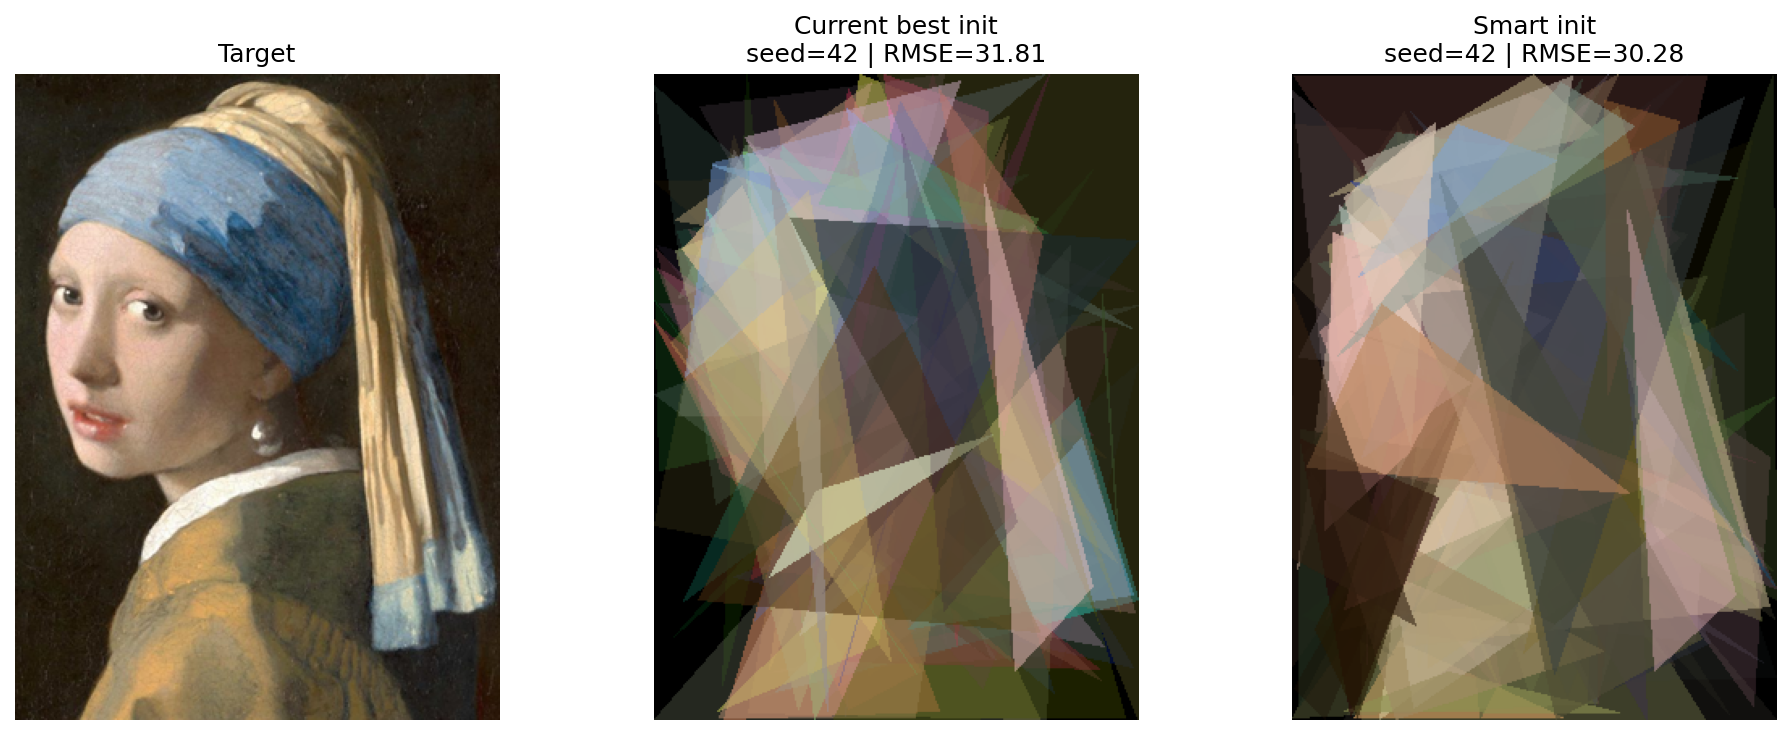

In [10]:
def best_result_for_mode(results: list[dict], mode: str) -> dict:
    subset = [r for r in results if r["mode"] == mode]
    return min(subset, key=lambda r: r["final_full_rmse"])


best_random = best_result_for_mode(comparison_results, "target_independent")
best_smart = best_result_for_mode(comparison_results, "smart")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].imshow(target)
axes[0].set_title("Target")
axes[0].axis("off")

for ax, result, title in [
    (axes[1], best_random, "Current best init"),
    (axes[2], best_smart, "Smart init"),
]:
    ax.imshow(render_individual(result["best_individual"]))
    ax.set_title(f"{title}\nseed={result['seed']} | RMSE={result['final_full_rmse']:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()
